# Exploratory data analysis(EDA)-data

![Iris](datos/img/Iris_flor.png)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = sns.load_dataset("iris")
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
# Tipos de datos, valores no nulos y memoria usada
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
print("Valores nulos por columna:")
print(data.isnull().sum())

print(f"\nRegistros duplicados: {data.duplicated().sum()}")
data[data.duplicated(keep=False)]

Valores nulos por columna:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Registros duplicados: 1


,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [5]:
#showing How many records are there for each species?
data["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

#3.Estadistica descriptiva

#3.1 Estadistica Generales

In [6]:
#Showing the medium , the mean , the standar standard deviation.min,cuartiles(25%,50%media,75%) y max

data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
#additional measures:rage,rinterquartile range 
# Medidas adicionales: rango, rango intercuartílico (IQR), coeficiente de variación, asimetría

num_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
num = data[num_cols]

resumen = pd.DataFrame({
    "media": num.mean(),
    "mediana": num.median(),
    "moda": num.mode().iloc[0],
    "desv_std": num.std(),
    "varianza":num.var(),
    "rango":num.max()-num.min(),
    "IQR":num.quantile(0.75)-num.quantile(0.25),
    "coef_variacion_%": num.std()/num.mean()*100,
    "asimetria":num.skew()


})

resumen

,media,mediana,moda,desv_std,varianza,rango,IQR,coef_variacion_%,asimetria
sepal_length,5.843333,5.80,5.0,0.828066,0.685694,3.6,1.3,14.171126,0.314911
sepal_width,3.057333,3.00,3.0,0.435866,0.189979,2.4,0.5,14.256420,0.318966
petal_length,3.758000,4.35,1.4,1.765298,3.116278,5.9,3.5,46.974407,-0.274884
petal_width,1.199333,1.30,0.2,0.762238,0.581006,2.4,1.5,63.555114,-0.102967


In [8]:
#Media y desviacion estándar de cada variable por especie
data.groupby('species')[num_cols].agg(['mean', 'std', 'min', 'max']).round(2).T

species            setosa  versicolor  virginica
sepal_length mean    5.01        5.94       6.59
             std     0.35        0.52       0.64
             min     4.30        4.90       4.90
             max     5.80        7.00       7.90
sepal_width  mean    3.43        2.77       2.97
             std     0.38        0.31       0.32
             min     2.30        2.00       2.20
             max     4.40        3.40       3.80
petal_length mean    1.46        4.26       5.55
             std     0.17        0.47       0.55
             min     1.00        3.00       4.50
             max     1.90        5.10       6.90
petal_width  mean    0.25        1.33       2.03
             std     0.11        0.20       0.27
             min     0.10        1.00       1.40
             max     0.60        1.80       2.50

In [9]:
#Area
data["sepal_area"]=data["sepal_length"]  *data["sepal_width"]
data["petal_area"]=data["petal_length"] * data["petal_width"]

#Ratio
data["sepal_ratio"]=data["sepal_length"]/data["sepal_width"]
data["petal_ratio"]=data["petal_length"]/data["petal_width"]

der_cols=["sepal_area","petal_area","sepal_ratio","petal_ratio"]
groupby=data.groupby("species")[der_cols].mean().round(2)
groupby




,sepal_area,petal_area,sepal_ratio,petal_ratio
species,,,,
setosa,17.26,0.37,1.47,6.91
versicolor,16.53,5.72,2.16,3.24
virginica,19.68,11.30,2.23,2.78


In [10]:
resultado=groupby["sepal_ratio"]*data["sepal_length"]
resultado

species
setosa       NaN
versicolor   NaN
virginica    NaN
0            NaN
1            NaN
              ..
145          NaN
146          NaN
147          NaN
148          NaN
149          NaN
Length: 153, dtype: float64

#GRAFICA DE CAJAS Y VIGOTES

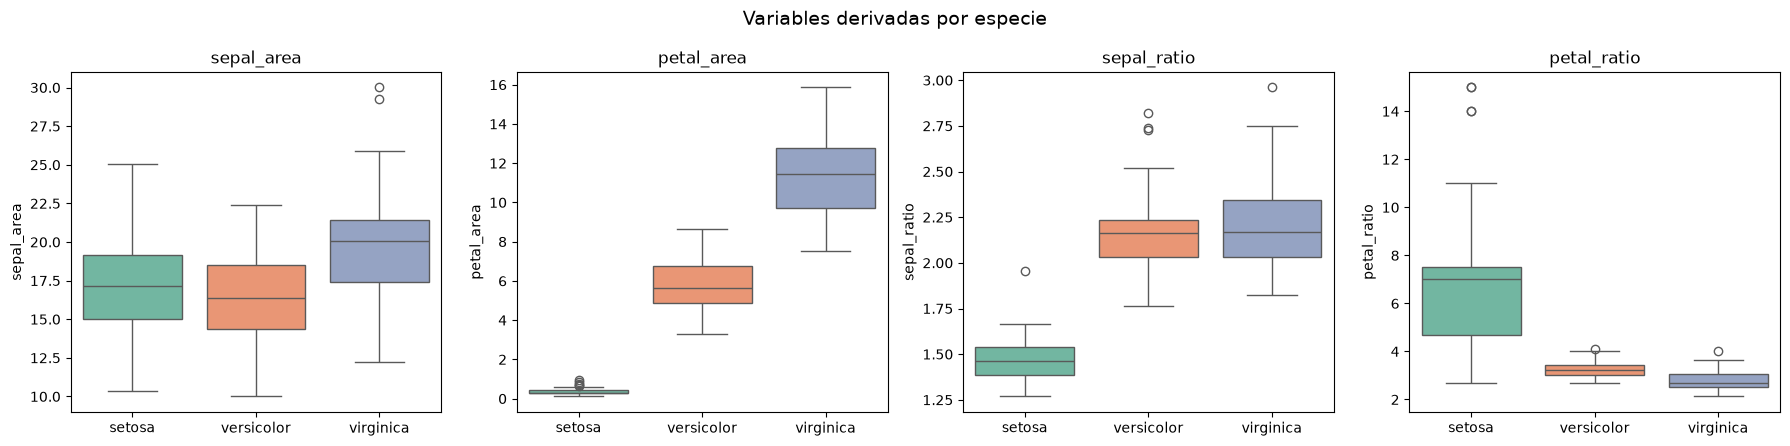

In [11]:
fig,axes=plt.subplots(1,4,figsize=(18,4.5))
for ax,col in zip(axes,der_cols):
    sns.boxplot(data=data,x="species",y=col,hue="species",palette="Set2",legend=False,ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Variables derivadas por especie",fontsize=14)
plt.tight_layout()
plt.show()

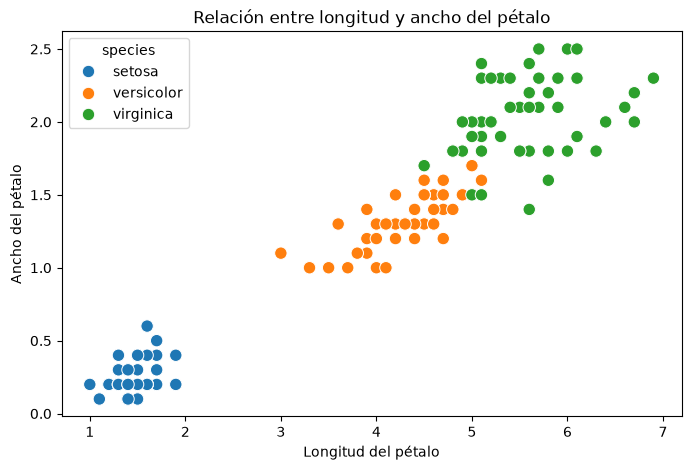

Se observa una relación positiva entre la longitud y el ancho del pétalo, ya que, en general, a medida que aumenta la longitud  del pétalo también aumenta su ancho. Además,
 las especies presentan agrupaciones diferenciadas, especialmente Setosa, cuyos valores de longitud y ancho de pétalo son considerablemente menores que los de Versicolor y Virginica.


In [15]:
#Scatter plot: petal length vs. petal width
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="petal_length",
    y="petal_width",
    hue="species",
    s=80
)

plt.title("Relación entre longitud y ancho del pétalo")
plt.xlabel("Longitud del pétalo")
plt.ylabel("Ancho del pétalo")
plt.show()

print("Se observa una relación positiva entre la longitud y el ancho del pétalo, ya que, en general, a medida que aumenta la longitud  del pétalo también aumenta su ancho. Además," +  "\n las especies presentan agrupaciones diferenciadas, especialmente Setosa, cuyos valores de longitud y ancho de pétalo son considerablemente menores que los de Versicolor y Virginica.")

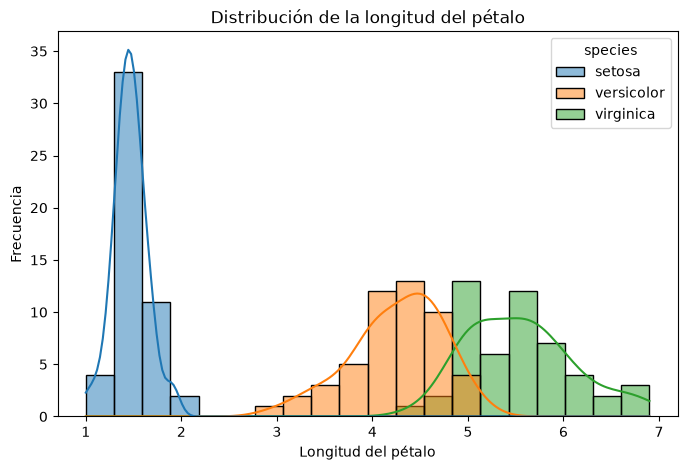

Se puede obvservar que tanto la versicolor como la virginica no tiene valores que tengan tanto dominancia en cambio la setosa si ya que cuenta con uan frecuencia de alrededor de 33 para las flores con tamaño de alrededor de 1.5 cm


In [17]:
#2. Histogram: distribution of petal length

plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="petal_length",
    hue="species",
    kde=True,
    bins=20
)

plt.title("Distribución de la longitud del pétalo")
plt.xlabel("Longitud del pétalo")
plt.ylabel("Frecuencia")
plt.show()

print("Se puede obvservar que tanto la versicolor como la virginica no tiene valores que tengan tanto dominancia en cambio la setosa si ya que cuenta con uan frecuencia de alrededor de 33 para las flores con tamaño de alrededor de 1.5 cm")

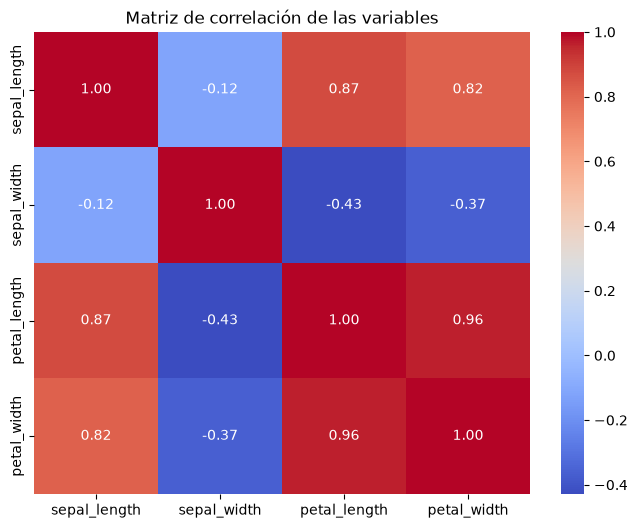

La matriz de correlación muestra una correlación positiva fuerte entre la longitud y el ancho del pétalo. Esto significa que las flores que presentan pétalos más largos tienden también
a presentar pétalos más anchos. También se observan relaciones positivas entre algunas de las variables del sépalo y las variables del pétalo, aunque con diferente intensidad


In [20]:
#3. Correlation heatmap
plt.figure(figsize=(8, 6))

corr = data[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables")
plt.show()

print("La matriz de correlación muestra una correlación positiva fuerte entre la longitud y el ancho del pétalo. Esto significa que las flores que presentan pétalos más largos tienden también" + "\na presentar pétalos más anchos. También se observan relaciones positivas entre algunas de las variables del sépalo y las variables del pétalo, aunque con diferente intensidad")